In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datasets import load_dataset

In [ ]:
emotion_dataset = load_dataset('dair-ai/emotion')
train_text      = emotion_dataset['train']['text']
train_label     = emotion_dataset['train']['label']

test_text       = emotion_dataset['test']['text']
test_label      = emotion_dataset['test']['label']

README.md:   0%|          | 0.00/9.05k [00:00<?, ?B/s]

split/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 1.03MB            

split/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/validation-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  127kB            

split/validation-00000-of-00001.parquet: downloading bytes:           |  0.00B            

split/test-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B /  129kB            

split/test-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/16000 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/2000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/2000 [00:00<?, ? examples/s]

In [ ]:
label_names = emotion_dataset['train'].features['label'].names

In [ ]:
label_names

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [ ]:
df_train = pd.DataFrame(
    {
        'text'  : train_text,
        'label' : [label_names[i] for i in train_label]
    }
)

df_test = pd.DataFrame(
    {
        'text'  : test_text,
        'label' : [label_names[i] for i in test_label]
    }
)

In [ ]:
df_train.isnull().sum()

,0
text,0
label,0


In [ ]:
df_train['label'].value_counts().index

Index(['joy', 'sadness', 'anger', 'fear', 'love', 'surprise'], dtype='object', name='label')

<Axes: xlabel='label', ylabel='count'>

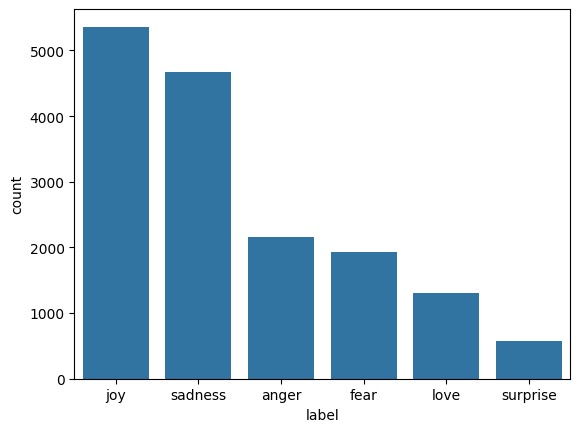

In [ ]:
sns.countplot(x='label', data=df_train, order=df_train['label'].value_counts().index)

In [ ]:
df_train

,text,label
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger
...,...,...
15995,i just had a very brief time in the beanbag an...,sadness
15996,i am now turning and i feel pathetic that i am...,sadness
15997,i feel strong and good overall,joy
15998,i feel like this was such a rude comment and i...,anger


In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='<unk>')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15213
Max Sentence Length: 50


In [ ]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [ ]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 42s 76ms/step - accuracy: 0.1469 - loss: 1.9106 - val_accuracy: 0.1155 - val_loss: 1.8120
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 31s 55ms/step - accuracy: 0.1575 - loss: 1.8034 - val_accuracy: 0.1060 - val_loss: 1.7980
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 64ms/step - accuracy: 0.1451 - loss: 1.7831 - val_accuracy: 0.1225 - val_loss: 1.7807
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 29s 58ms/step - accuracy: 0.1490 - loss: 1.7716 - val_accuracy: 0.1630 - val_loss: 1.7795
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 36s 71ms/step - accuracy: 0.1516 - loss: 1.7724 - val_accuracy: 0.1620 - val_loss: 1.7937
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 32s 53ms/step - accuracy: 0.1583 - loss: 1.7593 - val_accuracy: 0.1835 - val_loss: 1.7780
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 26s 52ms/step - accuracy: 0.1612 - loss: 1.7429 - val_accuracy: 0.2465 - val_loss: 1.7380
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 27s 55ms/step - accuracy: 0.1505 - loss: 1.7483 - 

In [ ]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 70s 132ms/step - accuracy: 0.1595 - loss: 1.7954 - val_accuracy: 0.3435 - val_loss: 1.7894
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 82s 133ms/step - accuracy: 0.1485 - loss: 1.7938 - val_accuracy: 0.0335 - val_loss: 1.8009
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 66s 132ms/step - accuracy: 0.1509 - loss: 1.7932 - val_accuracy: 0.2895 - val_loss: 1.7723
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.3435 - loss: 1.7894
LSTM Loss: 1.7893611192703247
LSTM Accuracy: 0.3434999883174896


In [ ]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 62s 116ms/step - accuracy: 0.1471 - loss: 1.7971 - val_accuracy: 0.0795 - val_loss: 1.8032
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 115ms/step - accuracy: 0.1674 - loss: 1.7946 - val_accuracy: 0.0330 - val_loss: 1.8095
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 58s 116ms/step - accuracy: 0.1363 - loss: 1.7949 - val_accuracy: 0.3490 - val_loss: 1.7494
63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.0795 - loss: 1.8032
GRU Loss: 1.8032258749008179
GRU Accuracy: 0.0794999971985817


In [ ]:
result_df = pd.DataFrame({
    'Model' : ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
    }).sort_values(by='Test Accuracy',ascending=False)
result_df

,Model,Test Loss,Test Accuracy
1,LSTM,1.789361,0.3435
0,RNN,1.688282,0.2905
2,GRU,1.803226,0.0795


Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.
Error: Runtime no longer has a reference to this dataframe, please re-run this cell and try again.


In [ ]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [ ]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 164s 316ms/step - accuracy: 0.5619 - loss: 1.0182 - val_accuracy: 0.8810 - val_loss: 0.3704
Epoch 2/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 204s 320ms/step - accuracy: 0.9129 - loss: 0.2408 - val_accuracy: 0.9170 - val_loss: 0.2492
Epoch 3/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 157s 314ms/step - accuracy: 0.9443 - loss: 0.1514 - val_accuracy: 0.9135 - val_loss: 0.2344
Epoch 4/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 217s 345ms/step - accuracy: 0.9567 - loss: 0.1161 - val_accuracy: 0.9235 - val_loss: 0.2277
Epoch 5/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 162s 324ms/step - accuracy: 0.9651 - loss: 0.0893 - val_accuracy: 0.9270 - val_loss: 0.2164
Epoch 6/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 161s 322ms/step - accuracy: 0.9781 - loss: 0.0626 - val_accuracy: 0.9195 - val_loss: 0.2616
Epoch 7/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 160s 320ms/step - accuracy: 0.9776 - loss: 0.0597 - val_accuracy: 0.9150 - val_loss: 0.3395
Epoch 8/20
500/500 ━━━━━━━━━━━━━━━━━━━━ 204s 326ms/step - accuracy: 0.9800 -

In [ ]:
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(padded_test_sequence, test_labels)
print(f"BiGRU Loss: {BiGRU_loss}")
print(f"BiGRU Accuracy: {BiGRU_accuracy}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 63ms/step - accuracy: 0.9270 - loss: 0.2164
BiGRU Loss: 0.2163780778646469
BiGRU Accuracy: 0.9269999861717224


63/63 ━━━━━━━━━━━━━━━━━━━━ 7s 101ms/step


<Axes: >

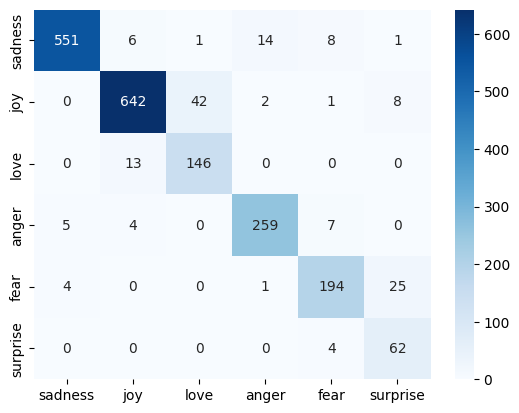

In [ ]:
from sklearn.metrics import confusion_matrix

BiGRU_predictions = np.argmax(BiGRU.predict(padded_test_sequence),axis=1)

sns.heatmap(confusion_matrix(test_label, BiGRU_predictions),annot=True, fmt='d', cmap='Blues', xticklabels=label_names, yticklabels=label_names)
#

In [ ]:
sample_texts = [
    "I can't believe how happy I am right now, this is amazing!",
    "I feel so alone and hopeless today.",
    "I am furious that they cancelled the trip at the last minute.",
    "I feel terrified when walking down dark alleyways alone.",
    "I was shocked and completely surprised by the unexpected gift!"
]

sample_sequences = tokenizer.texts_to_sequences(sample_texts)
sample_padded_sequences = pad_sequences(sample_sequences, maxlen=50, padding='post', truncating='post')

sample_predictions = np.argmax(BiGRU.predict(sample_padded_sequences), axis=1)

for i in range(len(sample_texts)):
  print(f'Text: {sample_texts[i]}\nPredicted Emotion: {label_names[sample_predictions[i]]}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
Text: I can't believe how happy I am right now, this is amazing!
Predicted Emotion: surprise
Text: I feel so alone and hopeless today.
Predicted Emotion: sadness
Text: I am furious that they cancelled the trip at the last minute.
Predicted Emotion: anger
Text: I feel terrified when walking down dark alleyways alone.
Predicted Emotion: fear
Text: I was shocked and completely surprised by the unexpected gift!
Predicted Emotion: surprise


In [ ]:
import os
import pickle

model_dir = 'Artifacts'
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Modle.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)